In [1]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt
from scipy.interpolate import interp1d

# define and load file
#infile = 'data/m50n512_151.hdf5'
#obj = caesar.load(infile)

In [2]:
from functions import *
unit = 'Mpc/h'

In [3]:
# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2023-12-19 12:24:55,405 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2023-12-19 12:24:55,494 Found 61977 halos
yt : [INFO     ] 2023-12-19 12:24:55,513 Found 5685 galaxies


(125, 0.49043513253694404)


In [4]:
# interpolation

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = [[i,np.log10(i.masses["stellar"])] for i in obj.galaxies]
# New sample (continuous values)
new_sample = np.array([i[1] for i in gal_stellar_mass])

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [5]:
# Randomly select indices based on the defined probabilities
# N//4
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample)//4, p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

1421


In [6]:
# get the galaxies corresponding to samples
# N//4
gal_sample1 = [j[0] for j in gal_stellar_mass for i in sample1 if i == j[1]]
print(len(gal_sample1))

1421


##### 1- normal distribution with *boxsize

In [189]:
# N//4

boxsize = np.array([obj.simulation.boxsize.to(unit)])
delta_n4 = boxsize/ len(gal_sample1)
pos_n4 = np.array([i.pos.to(unit) for i in gal_sample1])
np.random.seed(0)
new_pos_n4 = pos_n4 + (np.random.normal(0, delta_n4, (len(gal_sample1),3)))*boxsize

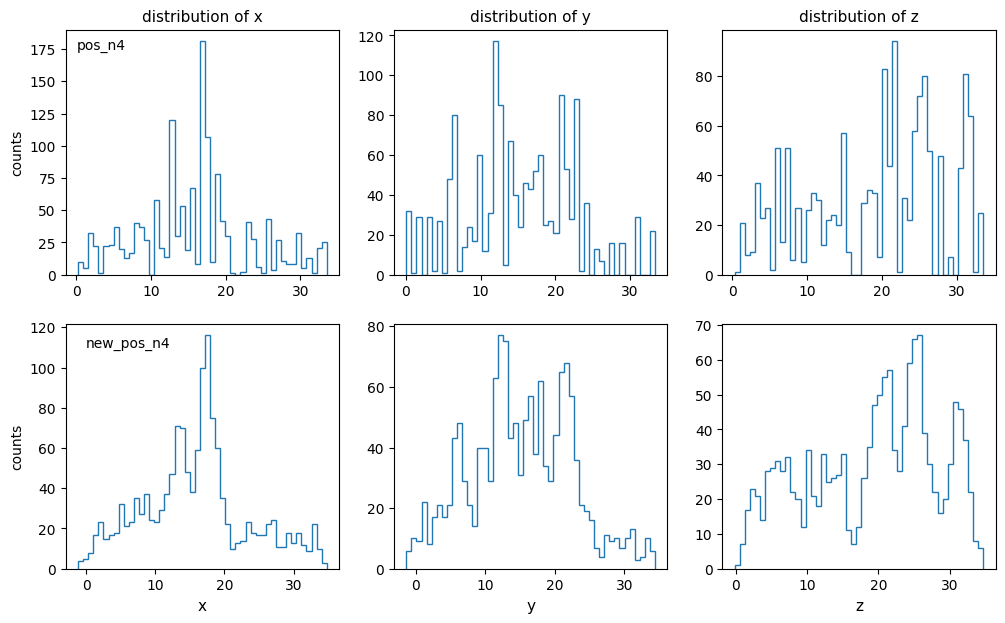

In [190]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(0,110,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [191]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.max(new_pos_n4)>boxsize*1.5)
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
34.77668524629619
34.38430415133567
34.68180880549528
[False]
-1.1575477112429748
-1.3755941775298979
-0.156693357983972


Apply periodic boundary

In [192]:
# periodic boundary

for i in range(3):
    new_pos_n4[:,i][new_pos_n4[:,i] > boxsize] %= boxsize

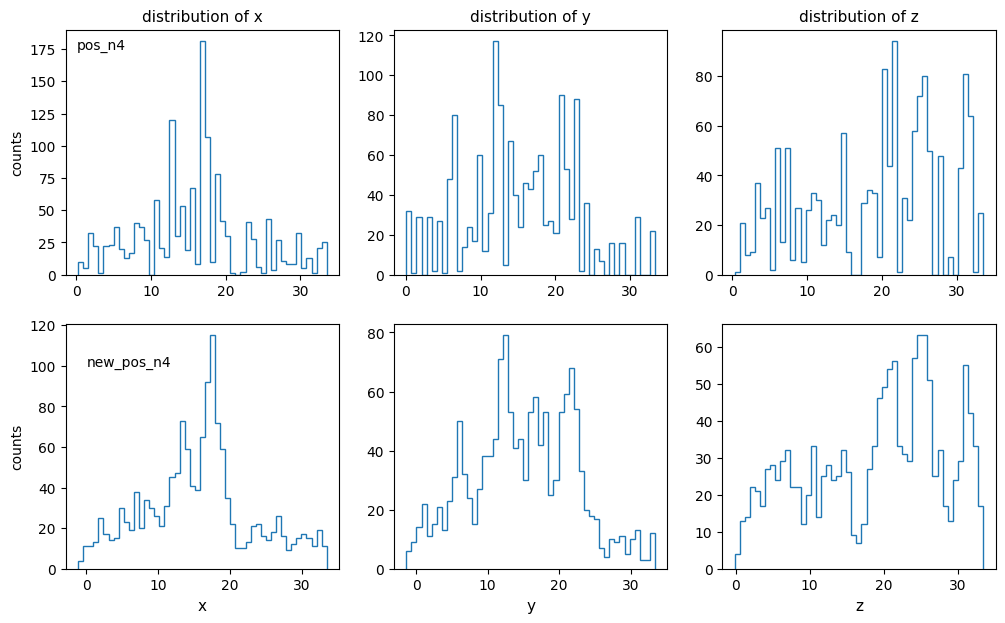

In [193]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(0,100,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [194]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
33.50315353201377
33.409921807053564
33.45740004997971
-1.1575477112429748
-1.3755941775298979
-0.156693357983972


##### 2- normal distribution without *boxsize

In [151]:
np.random.seed(0)
new_pos_n4 = pos_n4 + np.random.normal(0, delta_n4, (len(gal_sample1),3))

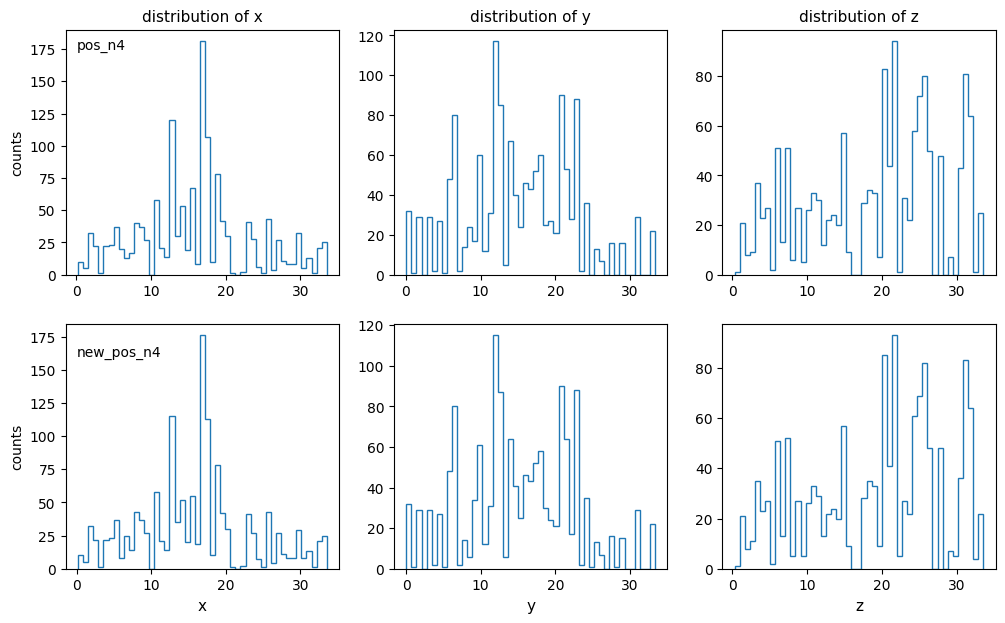

In [152]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(0,160,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [153]:
pos_n4[:5]

array([[ 7.6999056 ,  5.913514  , 12.98659707],
       [ 7.6999056 ,  5.913514  , 12.98659707],
       [ 7.6999056 ,  5.913514  , 12.98659707],
       [17.04730677, 21.37651969, 25.17630407],
       [17.04730677, 21.37651969, 25.17630407]])

In [154]:
new_pos_n4[:5]

array([[ 7.74155169,  5.92296099, 13.00970331],
       [ 7.75280905,  5.95760368, 12.9635253 ],
       [ 7.72233547,  5.90994073, 12.98416026],
       [17.05700026, 21.3799203 , 25.21063685],
       [17.0652735 , 21.37939222, 25.18678288]])

In [155]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
33.52061644579841
33.36565412026353
33.55127161153792
0.19164687177036172
0.026131659736456016
0.32744524356224514


Apply periodic boundary

In [156]:
# periodic boundary

for i in range(3):
    new_pos_n4[:,i][new_pos_n4[:,i] > boxsize] %= boxsize

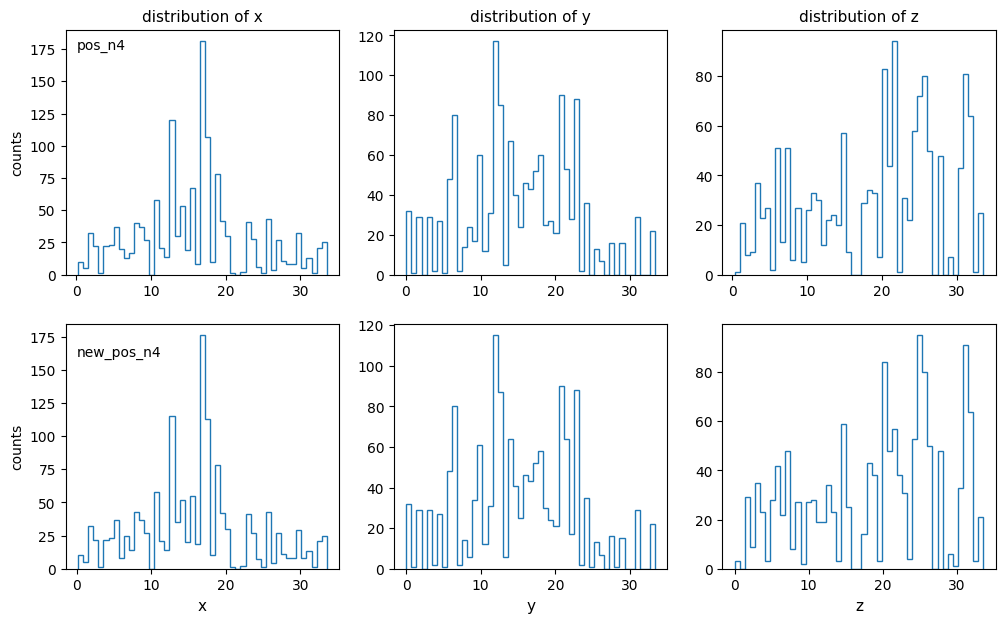

In [157]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(0,160,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [158]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
33.52061644579841
33.36565412026353
33.5471756673063
0.19164687177036172
0.026131659736456016
0.0031655846266005483


##### 3- uniform distribution with *boxsize

In [195]:
np.random.seed(0)
new_pos_n4 = pos_n4 + (np.random.uniform(0, boxsize, (len(gal_sample1),3))) * boxsize

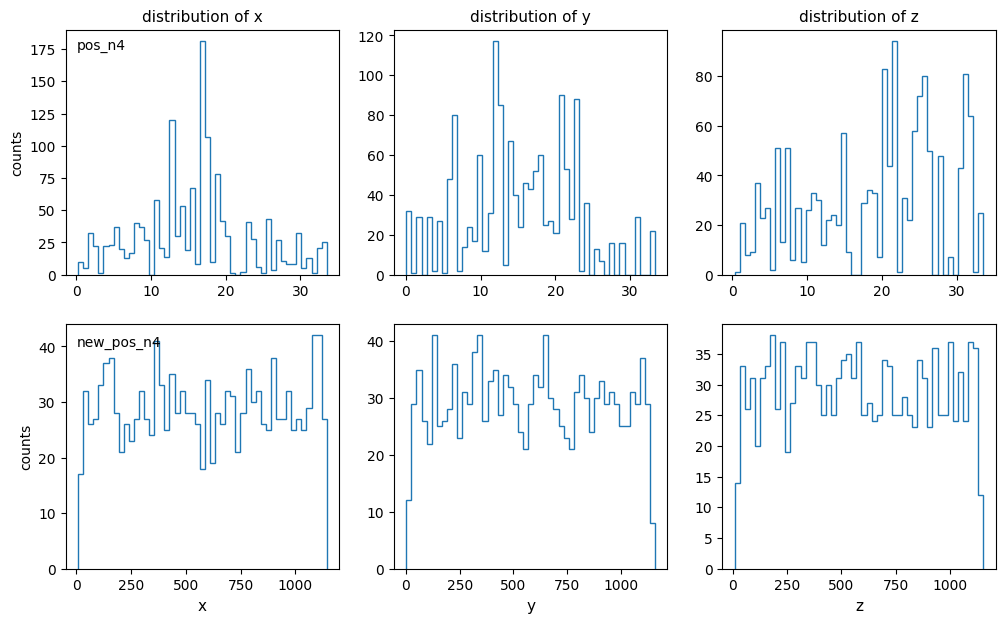

In [196]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(0,40,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [197]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
1143.7239088056747
1158.6948889335981
1150.699655418084
7.8166196660802285
1.626046009427217
9.018052662278263


Apply periodic boundary

In [198]:
# periodic boundary

for i in range(3):
    new_pos_n4[:,i][new_pos_n4[:,i] > boxsize] %= boxsize

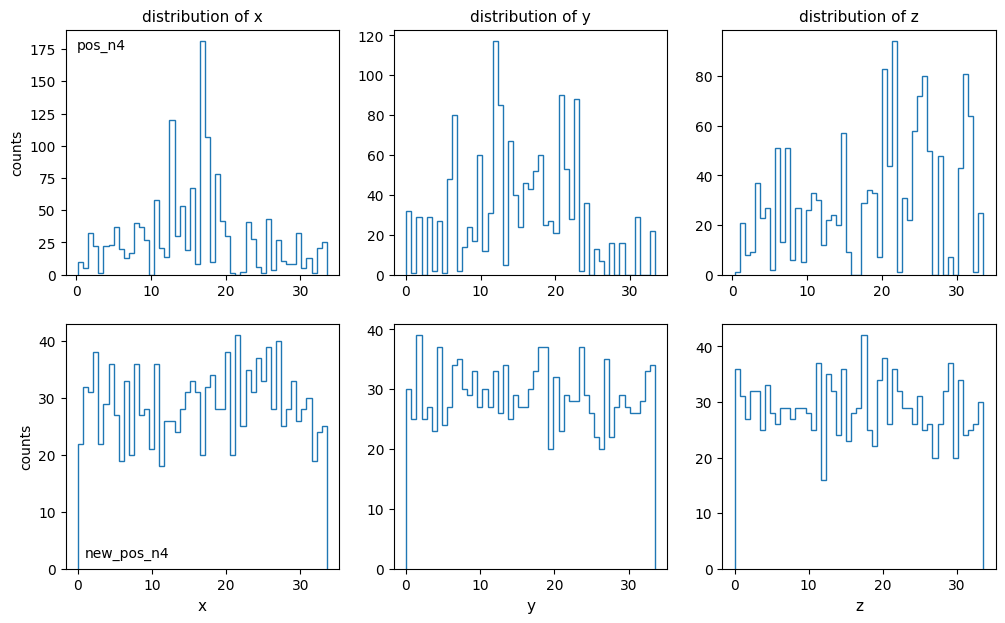

In [199]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(1,2,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [200]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
33.53496741903945
33.53418574107417
33.53584898902619
0.05216277091409438
0.05755183732469504
0.003111100660419197


##### 4- uniform distribution without *boxsize

In [201]:
np.random.seed(0)
new_pos_n4 = pos_n4 + np.random.uniform(0, boxsize, (len(gal_sample1),3))

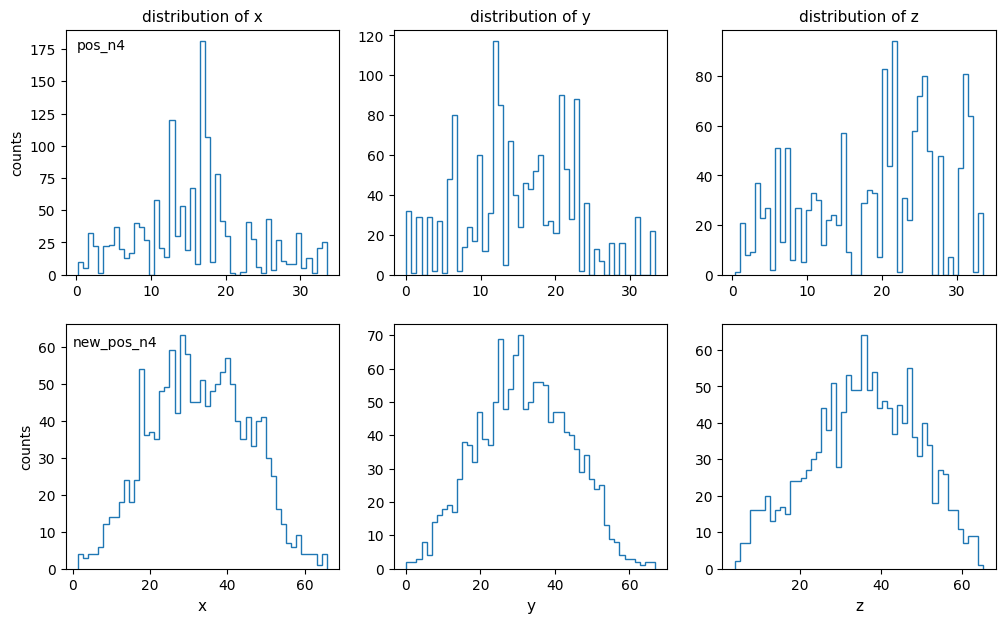

In [202]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(0,60,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [203]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
65.63986703975469
66.8798943319147
65.28565157046464
1.4194127469294273
0.11560666034236806
3.8890997823858675


Apply periodic boundary

In [204]:
# periodic boundary

for i in range(3):
    new_pos_n4[:,i][new_pos_n4[:,i] > boxsize] %= boxsize

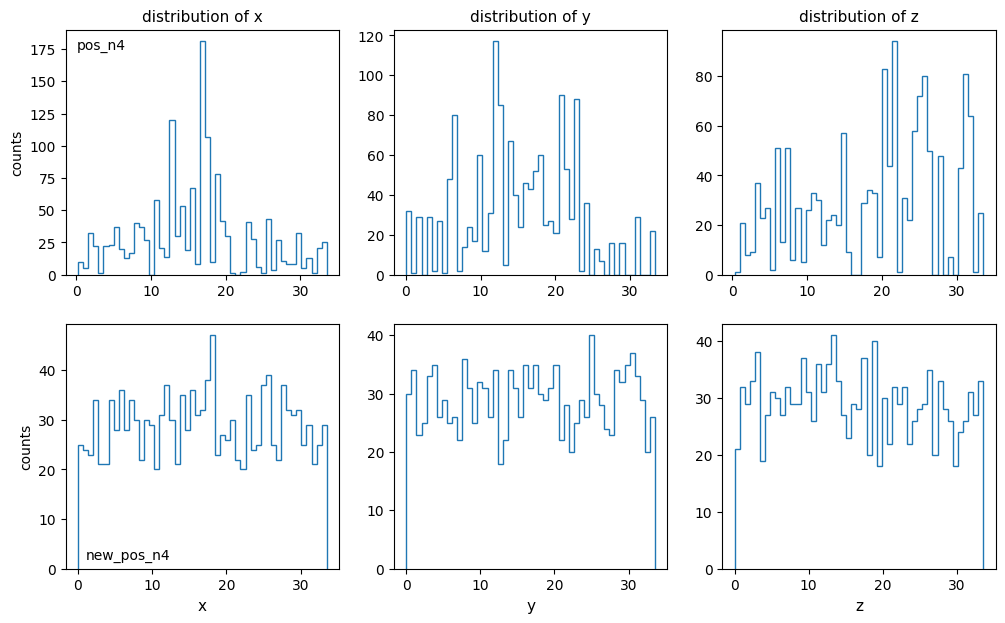

In [205]:
bin00 = np.linspace(np.min(pos_n4[:,0]),max(pos_n4[:,0]),50)
bin01 = np.linspace(np.min(pos_n4[:,1]),max(pos_n4[:,1]),50)
bin02 = np.linspace(np.min(pos_n4[:,2]),max(pos_n4[:,2]),50)
bin10 = np.linspace(np.min(new_pos_n4[:,0]),max(new_pos_n4[:,0]),50)
bin11 = np.linspace(np.min(new_pos_n4[:,1]),max(new_pos_n4[:,1]),50)
bin12 = np.linspace(np.min(new_pos_n4[:,2]),max(new_pos_n4[:,2]),50)

fig, ax = plt.subplots(2,3, figsize=(12,7))
ax[0][0].hist(pos_n4[:,0], bins=bin00, histtype='step')
ax[0][0].set_title('distribution of x', fontsize=11)
#ax[0][0].set_xlabel('x', fontsize=11)
ax[0][0].set_ylabel('counts')
ax[0][0].text(0,175,'pos_n4')

ax[0][1].hist(pos_n4[:,1], bins=bin01, histtype='step')
ax[0][1].set_title('distribution of y', fontsize=11)
#ax[0][1].set_xlabel('y', fontsize=11)

ax[0][2].hist(pos_n4[:,2], bins=bin02, histtype='step')
ax[0][2].set_title('distribution of z', fontsize=11)
#ax[0][2].set_xlabel('z', fontsize=11)

ax[1][0].hist(new_pos_n4[:,0], bins=bin10, histtype='step')
#ax[1][0].set_title('distribution of x', fontsize=11)
ax[1][0].set_xlabel('x', fontsize=11)
ax[1][0].set_ylabel('counts')
ax[1][0].text(1,2,'new_pos_n4')

ax[1][1].hist(new_pos_n4[:,1], bins=bin11, histtype='step')
#ax[1][1].set_title('distribution of y', fontsize=11)
ax[1][1].set_xlabel('y', fontsize=11)

ax[1][2].hist(new_pos_n4[:,2], bins=bin12, histtype='step')
#ax[1][2].set_title('distribution of z', fontsize=11)
ax[1][2].set_xlabel('z', fontsize=11);

In [206]:
print(boxsize)
print(np.max(new_pos_n4[:,0]))
print(np.max(new_pos_n4[:,1]))
print(np.max(new_pos_n4[:,2]))
print(np.min(new_pos_n4[:,0]))
print(np.min(new_pos_n4[:,1]))
print(np.min(new_pos_n4[:,2]))

[33.5472497]
33.51708107840953
33.538846100405806
33.53450622425838
0.01826566156136522
0.043210052248653597
0.006955367808430424
